#듀오링고 앱 사용자 불만 요인 분석 및 개선 방향 제시

최근에 새로운 언어 학습을 시작하면서 Duolingo도 함께 사용하고 있다. 듀오링고는 전세계에서 3억명이 넘는 사용자가 있으며 34개의 언어의 코스를 제공하는 세계적인 서비스이다. 그러나 이처럼 널리 사용되는 앱임에도 불구하고, 사용 중 정답처리 오류라든지, 번역 이상함을 느꼈다. 이는 단지 개인의 문제가 아니라 다른 사용자도 필히 비슷한 불편함을 겪고 있을 것이라 생각했다

이에 본 프로젝트에서는 듀오링고의 구글 플레이 리뷰 데이터를 수집하여, 실제 사용자들이 어떤 점에서 불편함을 많이 느끼는지 분석하고자 한다. 특히, 리뷰를 감성 분석, 키워드 분석, 클러스터링 등의 기법을 통해 정제하고, 사용자 불만의 주요 원인을 파악하여 향후 듀오링고가 개선할 수 있는 방향에 대한 인사이트를 도출하는 것을 목표로 한다.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/drive/MyDrive/Term_Project

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Term_Project


In [2]:
!pip install google-play-scraper pandas

In [3]:
!pip install pandas scikit-learn nltk

In [4]:
!pip install transformers torch --quiet

In [5]:
!pip install --upgrade pyldavis[sklearn]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.7/26.7 MB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 47.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.3
    Uninstalling scipy-1.15.3:
      Successfully uninstalled scipy-1.15.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you ha

In [5]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from transformers import pipeline
from collections import Counter
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer
import pyLDAvis
import pyLDAvis.lda_model
from scipy.stats import chi2_contingency
from wordcloud import WordCloud
from sklearn.cluster import KMeans
from scipy.stats import chisquare

## 데이터 수집

구글 플레이스토어에서의 영문 리뷰를 수집했다.
review id, 작성 시간, 리뷰 점수, 내용을 수집했고, 최신순이 아닌 공감수가 많았던 리뷰를 기준으로 수집했다.

In [ ]:
from google_play_scraper import Sort,reviews_all
app_package_name = 'com.duolingo'

all_reviews = reviews_all(
    app_package_name,
    lang='en',
    country='us',
    sleep_milliseconds=0,
    sort=Sort.MOST_RELEVANT
)

df = pd.DataFrame(all_reviews)
df = df[['reviewId','at','score','thumbsUpCount', 'content']]

print(f"리뷰 수: {len(df)}")

df.to_csv('./duolingo_all.csv', index=False)

print("데이터 수집 완료")

리뷰 수: 90000
데이터 수집 완료


In [ ]:
print(df['at'].min())
print(df['at'].max())
print(df.head())
print(df.info())

2018-09-12 09:34:55
2025-06-19 18:00:07
                               reviewId                  at  score  \
0  12916ec6-de67-42ca-a0e3-94c01fa805ea 2025-06-14 03:13:50      2   
1  fe8fedaa-60cf-4d4f-b368-9075c1bad538 2025-06-06 13:58:20      2   
2  d919099f-7692-4cb4-b304-835a974d847e 2025-06-05 01:06:47      2   
3  b8579d48-9106-4450-b758-403d2159c0fd 2025-06-07 00:53:11      3   
4  118613b5-29fe-40a6-80f3-416b8fc72607 2025-06-10 17:46:17      3   

   thumbsUpCount                                            content  
0             37  I have been using this app for years and I abs...  
1            113  Love this app, even have a family membership. ...  
2            139  free access is an absolute joke. God forbid yo...  
3             70  The widget doesn't stay on my homescreen for w...  
4             37  Still not a huge fan of "the path". French, Sp...  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 5 columns):
 #   Column

2018년 9월 12일부터 2025년 6월 19일까지의 약 58,000개의 리뷰를 수집했다.

## 데이터 확인

In [6]:
df = pd.read_csv('./duolingo_all.csv')

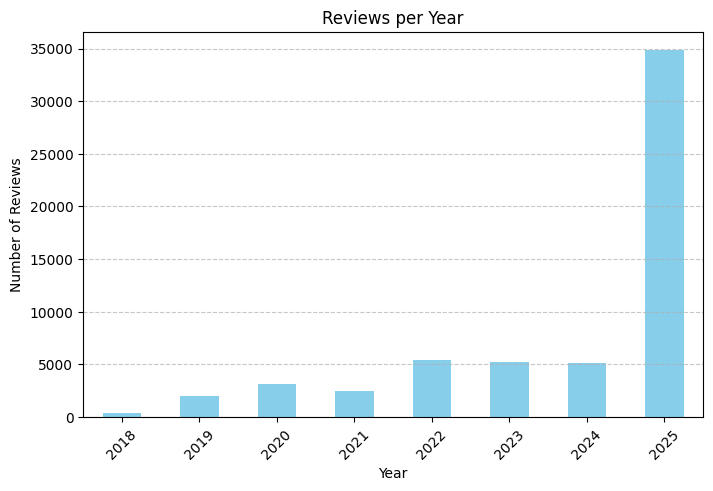

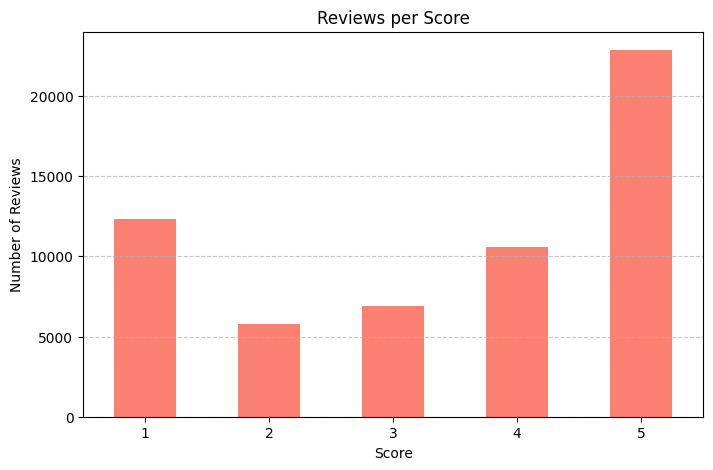

In [7]:
# 리뷰 분포 확인

# 년도별 리뷰 개수
df['at'] = pd.to_datetime(df['at'])
df['year'] = df['at'].dt.year
yearly_reviews = df.groupby('year').size()

plt.figure(figsize=(8,5))
yearly_reviews.plot(kind='bar', color='skyblue')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.title('Reviews per Year')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# score별 리뷰 개수
score_reviews = df['score'].value_counts().sort_index()

plt.figure(figsize=(8,5))
score_reviews.plot(kind='bar', color='salmon')
plt.xlabel('Score')
plt.ylabel('Number of Reviews')
plt.title('Reviews per Score')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [8]:
# 리뷰 점수별 tf-idf 키워드 분석
nltk.download('stopwords')
stop_words = stopwords.words('english')
add_stopwords = stop_words + [
    'app', 'duolingo', 'get', 'really', 'im', 'like', 'use', 'used', 'using', 'make',
    'lot', 'thing', 'one', 'even', 'still', 'way', 'also','learn','learning','would'
]

# 결측치 제거
df = df.dropna(subset=['content', 'score'])
df['content'] = df['content'].astype(str)
df['score'] = df['score'].astype(int)

# 전처리 함수
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['cleaned'] = df['content'].apply(clean_text)

# 별점별로 tf-idf
def top_tfidf_words_by_score(score, top_n=10):
    group = df[df['score'] == score]['cleaned'].tolist()
    if len(group) < 5:
        return f"Score {score}: Not enough reviews"

    vectorizer = TfidfVectorizer(stop_words=add_stopwords, max_df=0.95, min_df=2)
    tfidf = vectorizer.fit_transform(group)
    words = vectorizer.get_feature_names_out()
    avg_tfidf = tfidf.mean(axis=0).A1
    top_indices = avg_tfidf.argsort()[::-1][:top_n]
    return [(words[i], round(avg_tfidf[i], 4)) for i in top_indices]

# score별 결과 보기
for s in range(1, 6):
    print(f"\n Score {s} Reviews:")
    print(top_tfidf_words_by_score(s))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.



 Score 1 Reviews:
[('ai', 0.0323), ('language', 0.0256), ('new', 0.0233), ('ads', 0.0215), ('lessons', 0.0205), ('dont', 0.0201), ('update', 0.0191), ('hearts', 0.0191), ('time', 0.0179), ('lesson', 0.0169)]

 Score 2 Reviews:
[('language', 0.0256), ('ads', 0.0244), ('new', 0.023), ('lessons', 0.0228), ('dont', 0.0212), ('hearts', 0.0206), ('good', 0.0206), ('lesson', 0.0203), ('time', 0.0188), ('update', 0.0178)]

 Score 3 Reviews:
[('language', 0.0295), ('good', 0.0265), ('ads', 0.022), ('dont', 0.0217), ('lessons', 0.021), ('new', 0.0194), ('lesson', 0.0193), ('great', 0.0192), ('words', 0.0187), ('hearts', 0.0177)]

 Score 4 Reviews:
[('language', 0.0386), ('good', 0.0365), ('great', 0.0267), ('languages', 0.0263), ('fun', 0.0209), ('new', 0.0208), ('dont', 0.0193), ('words', 0.0188), ('lessons', 0.0182), ('love', 0.0178)]

 Score 5 Reviews:
[('language', 0.0531), ('languages', 0.0407), ('good', 0.0357), ('fun', 0.0345), ('love', 0.0293), ('best', 0.0291), ('new', 0.0267), ('easy'

리뷰 점수가 1점인 리뷰에서 "AI"가 대표적인 키워드라고 나왔다. 다른 리뷰에서는 순위 안에 들지 않은 것을 볼 때, ai가 듀오링고의 중요한 불만 포인트임을 확인할 수 있다.

## 가설1: AI 도입이 듀오링고 사용자 경험에 부정적인 영향을 미쳤을 것이다

In [9]:
def mention_ai(text):
    return bool(re.search(r'\bai\b', text.lower()))

df['ai_mentioned'] = df['cleaned'].apply(mention_ai)

In [10]:
ai_ratio = df.groupby('score')['ai_mentioned'].mean().round(3)
print(ai_ratio)

score
1    0.239
2    0.077
3    0.030
4    0.010
5    0.003
Name: ai_mentioned, dtype: float64


확실히 score가 낮아질수록 AI에 대한 언급빈도가 높아졌다.

듀오링고는 2023년 3월 일부 기능에 AI를 도입했지만, 2023년 말에 본격적으로 번역 품질 개선을 위해 계약직 인력을 감축하고 AI기반 번역에 의존하기 시작하였다.
따라서 2024년 1월을 기준으로 하여 AI 도입 전후 사용자 리뷰를 분리하고 각각의 주요 키워드를 비교 분석하였다.

In [11]:
# 2024년 1월 기준으로 분리
pre_ai = df[df['at'] < '2024-01-01'].copy()
post_ai = df[df['at'] >= '2024-01-01'].copy()

# 전처리 함수 정의

stop_words = set(stopwords.words('english'))
add_stopwords = { 'app', 'duolingo', 'get', 'really', 'im', 'like', 'use', 'used', 'using', 'make',
    'lot', 'thing', 'one', 'even', 'still', 'way', 'also','learn','learning','would'}
stop_words.update(add_stopwords)
stemmer = PorterStemmer()

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = text.split()
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# 전처리 적용
pre_ai['cleaned'] = pre_ai['content'].apply(preprocess)
post_ai['cleaned'] = post_ai['content'].apply(preprocess)

In [12]:
#TF-IDF 비교 분석 코드
def get_top_tfidf_words(corpus, top_n=20):
    vectorizer = TfidfVectorizer(max_df=0.9, min_df=10)
    X = vectorizer.fit_transform(corpus)
    tfidf_scores = X.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    sorted_idx = tfidf_scores.argsort()[::-1]
    return [(terms[i], tfidf_scores[i]) for i in sorted_idx[:top_n]]

pre_top_words = get_top_tfidf_words(pre_ai['cleaned'])
post_top_words = get_top_tfidf_words(post_ai['cleaned'])

print(" AI 도입 이전 키워드:")
for word, score in pre_top_words:
    print(f"{word}: {score:.4f}")

print("\n AI 도입 이후 주요 키워드:")
for word, score in post_top_words:
    print(f"{word}: {score:.4f}")

 AI 도입 이전 키워드:
languag: 912.8195
lesson: 645.7144
new: 568.6864
good: 466.9294
great: 465.2674
time: 444.5801
word: 425.3505
updat: 412.4813
help: 397.8005
ad: 385.6243
dont: 382.0724
free: 371.0516
heart: 363.7195
love: 362.8343
want: 362.2564
fun: 354.6752
day: 352.0780
ive: 342.6058
much: 339.2063
make: 337.2520

 AI 도입 이후 주요 키워드:
languag: 2417.2801
good: 1388.8150
help: 1209.7607
fun: 1097.6393
lesson: 1000.6620
love: 981.9375
ad: 959.1695
new: 915.0817
great: 908.0117
best: 845.6158
want: 767.3987
easi: 766.7909
english: 745.2587
time: 740.0208
word: 735.6682
dont: 716.5491
day: 696.7838
much: 693.5014
heart: 681.0514
ai: 668.1668


20위지만 AI 도입 이후 AI 언급 빈도가 높아졌음을 확인할 수 있다.

In [13]:
# 1~2점 리뷰만 추출
low_score = df[df['score'].isin([1, 2])].dropna(subset=['content'])
low_score['clean_text'] = low_score['content'].str.lower()

# 2024년 기준으로 분할
before_2024 = low_score[low_score['at'] < '2024-01-01']
after_2024 = low_score[low_score['at'] >= '2024-01-01']

# TF-IDF 함수
def extract_tfidf(corpus, label):
    vectorizer = TfidfVectorizer(max_features=20, stop_words='english')
    X = vectorizer.fit_transform(corpus)
    scores = X.sum(axis=0).A1
    words = vectorizer.get_feature_names_out()
    result = sorted(zip(words, scores), key=lambda x: x[1], reverse=True)
    print(f"\n {label} 상위 키워드:")
    for word, score in result:
        print(f"{word}: {score:.4f}")

extract_tfidf(before_2024['clean_text'], "2024년 이전")
extract_tfidf(after_2024['clean_text'], "2024년 이후")


 2024년 이전 상위 키워드:
app: 1338.8871
learning: 891.9688
new: 859.1495
update: 723.9154
duolingo: 708.0894
lessons: 665.4646
just: 627.2476
learn: 608.4986
language: 582.4974
like: 562.6034
used: 519.2219
really: 506.7474
time: 502.8950
ve: 491.9800
don: 491.8450
lesson: 484.3331
progress: 448.0297
version: 440.0305
use: 434.2890
way: 428.6076

 2024년 이후 상위 키워드:
app: 2639.9580
ai: 1766.0361
duolingo: 1477.4577
learning: 1433.6636
language: 1265.1639
just: 1133.3504
ads: 1097.3751
learn: 1053.6368
don: 946.0121
like: 928.0913
lessons: 903.6982
time: 887.2839
hearts: 837.8178
used: 817.1601
use: 800.0693
lesson: 784.1138
good: 782.7833
ve: 780.0087
streak: 760.3211
practice: 688.1255


score가 낮은 리뷰의 TF-IDF를 분석했을 때 더 두드러지게 AI 언급률이 나타났다.

명확하게 2024년 이후 AI 언급률이 늘어났으며, 이는 점수가 낮은 리뷰에서 더 확연하게 결과로 나타났다.

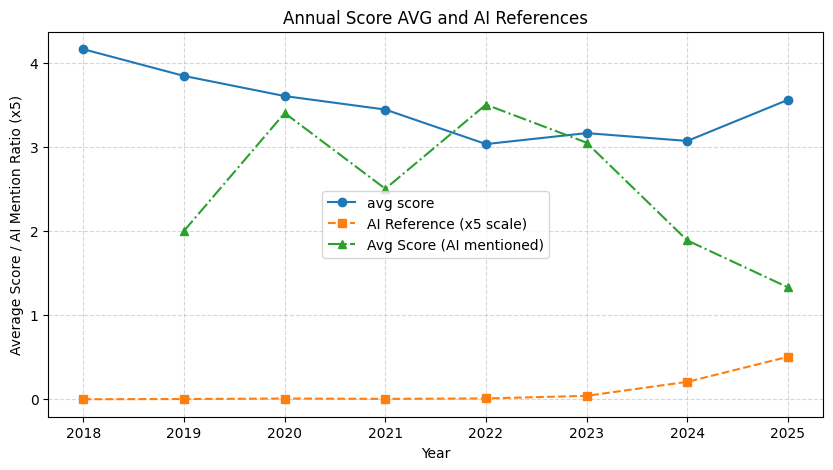

In [14]:
# 연도별 평균 평점
yearly_score = df.groupby('year')['score'].mean()
# 연도별 AI 언급 비율
yearly_ai_ratio = df.groupby('year')['ai_mentioned'].mean()
# 연도별 평균 평점(AI 언급된 리뷰)
ai_score_by_year = df[df['ai_mentioned']].groupby('year')['score'].mean()

plt.figure(figsize=(10, 5))
plt.plot(yearly_score.index, yearly_score.values, label='avg score', marker='o')
plt.plot(yearly_ai_ratio.index, yearly_ai_ratio.values * 5, label='AI Reference (x5 scale)', marker='s', linestyle='--')
plt.plot(ai_score_by_year.index, ai_score_by_year.values,
         label='Avg Score (AI mentioned)', marker='^', linestyle='-.')
plt.title("Annual Score AVG and AI References")
plt.xlabel("Year")
plt.ylabel("Average Score / AI Mention Ratio (x5)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


2023년부터 AI 언급률이 계속해서 상승하고, AI 언급된 리뷰들의 score 또한 크게 하락하고 있음을 확인할 수 있다.
구체적인 수치 비교를 위해 아래와 같이 2024년과 2025년에 AI 언급된 리뷰 수, 그에 대한 score가 낮은 리뷰 수, score가 높은 리뷰 수의 비율을 비교했다.

In [15]:
# 연도별 필터링
ai_mentioned = df[df['ai_mentioned']]
ai_2024 = ai_mentioned[ai_mentioned['at'].dt.year == 2024]
ai_2025 = ai_mentioned[ai_mentioned['at'].dt.year == 2025]

ai_2024['clean_text'] = ai_2024['content'].str.lower()
ai_2025['clean_text'] = ai_2025['content'].str.lower()

total_2024 = len(ai_2024)
pos_2024 = len(ai_2024[ai_2024['score'] >= 4])
neg_2024 = len(ai_2024[ai_2024['score'] <= 2])

print(f"2024 | 전체: {total_2024}개")
print(f"긍정 리뷰: {pos_2024}개 ({pos_2024 / total_2024:.2%})")
print(f"부정 리뷰: {neg_2024}개 ({neg_2024 / total_2024:.2%})\n")
print( {"year" : "2024", "positive": pos_2024 / total_2024, "negative": neg_2024 / total_2024})

total_2025 = len(ai_2025)
pos_2025 = len(ai_2025[ai_2025['score'] >= 4])
neg_2025 = len(ai_2025[ai_2025['score'] <= 2])

print(f"2025 | 전체: {total_2025}개")
print(f"긍정 리뷰: {pos_2025}개 ({pos_2025 / total_2025:.2%})")
print(f"부정 리뷰: {neg_2025}개 ({neg_2025 / total_2025:.2%})\n")
print( {"year" : "2025", "positive": pos_2025 / total_2025, "negative": neg_2025 / total_2025})

2024 | 전체: 211개
긍정 리뷰: 22개 (10.43%)
부정 리뷰: 160개 (75.83%)

{'year': '2024', 'positive': 0.10426540284360189, 'negative': 0.7582938388625592}
2025 | 전체: 3510개
긍정 리뷰: 131개 (3.73%)
부정 리뷰: 3216개 (91.62%)

{'year': '2025', 'positive': 0.037321937321937323, 'negative': 0.9162393162393162}


/tmp/ipython-input-15-1541188030.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai_2024['clean_text'] = ai_2024['content'].str.lower()
/tmp/ipython-input-15-1541188030.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ai_2025['clean_text'] = ai_2025['content'].str.lower()


확연하게 리뷰 개수도 많아졌을 뿐만 아니라, 부정적인 score가 나온 리뷰의 비율이 75.83에서 91.62로 약 16퍼센트 증가하였다.
(다운받는 과정에서 최근 리뷰가 더 많이 다운된 사실을 염두에 두어야 한다. 그럼에도 이 수치는 AI 기능 도입 이후 사용자 불만이 실제로 증가했을 가능성을 시사한다.)

이번에는 AI_mentioned 리뷰와 not mentioned 리뷰의 감성분석을 통해 AI 언급 여부에 따라 감성 차이가 존재하는지 확인해볼 것이다.

In [16]:
sentiment_pipeline = pipeline("sentiment-analysis")

# 샘플 리뷰 100개만 분석
sample_texts = df[df['ai_mentioned']]['content'].dropna().astype(str).sample(100, random_state=42).tolist()

# 감성 분석
results = sentiment_pipeline(sample_texts)
sentiment_counts = Counter([r['label'] for r in results])
print("AI 언급 리뷰 감성 점수",sentiment_counts)

# not mentioned
sample_non_ai = df[df['ai_mentioned'] == False]['content'].dropna().astype(str).sample(100, random_state=0).tolist()
results_non_ai = sentiment_pipeline(sample_non_ai)
sentiment_counts_non_ai = Counter([r['label'] for r in results_non_ai])
print("AI 언급 안된 리뷰 감성 점수",sentiment_counts_non_ai)

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


AI 언급 리뷰 감성 점수 Counter({'NEGATIVE': 95, 'POSITIVE': 5})
AI 언급 안된 리뷰 감성 점수 Counter({'POSITIVE': 54, 'NEGATIVE': 46})


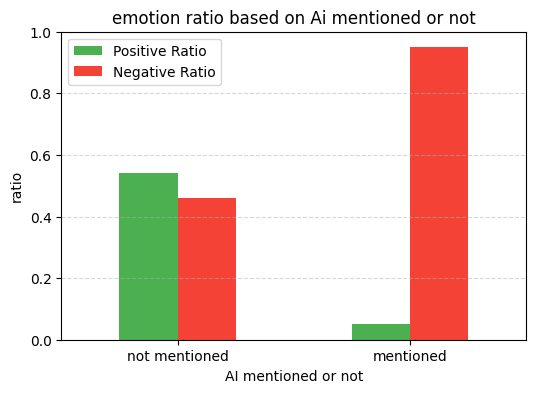

In [17]:
# 그래프로 표현

sentiment_summary = pd.DataFrame({
    'AI mentioned or not': ['not mentioned', 'mentioned'],
    'Positive Ratio': [0.54, 0.05],
    'Negative Ratio': [0.46, 0.95]
})

# 막대그래프
sentiment_summary.set_index('AI mentioned or not').plot(kind='bar', figsize=(6, 4), color=['#4caf50', '#f44336'])
plt.title('emotion ratio based on Ai mentioned or not')
plt.ylabel('ratio')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.show()


ai가 언급안된 리뷰에서는 positive가 0.54, negative가 0.46으로 나왔고, ai가 언급된리뷰는 positive가 0.05, negative가 0.95로 나왔다. ai기능 자체가 평점과 감정 모두에 영향을 줌을 확인할 수 있다.

## 가설2: 언어 학습 레벨(초보/고급)이 높을수록 결제를 할 가능성이 높다.

In [18]:
def classify_level_improved(text):
    text = text.lower()

    # Advanced
    experience_signals = [
        'used to know', 'losing', 'refresh', 'used for years',
        'too easy', 'nearly impossible to use', 'used duolingo for years',
        'i used', 'been using'
    ]

    # Beginners
    beginner_signals = [
        'as a beginner', 'just started', 'new to', 'first time',
        'i chose', 'start out simple', 'never', 'beginning'
    ]

    # Recommending Signals
    recommending_signals = [
        'good for beginners', 'excellent for beginners',
        'would be good for', 'great for beginners'
    ]

    # 부정문 처리
    if any(neg in text for neg in ['not a beginner', "isn't beginner", 'no longer beginner']):
        return 'Advanced'

    if any(sig in text for sig in experience_signals):
        return 'Advanced'
    elif any(sig in text for sig in beginner_signals) and not any(sig in text for sig in recommending_signals):
        return 'Beginner'
    else:
        return 'None'

def classify_payment_improved(text):
    text = text.lower()

    # Paid
    paid_signals = [
        'paid', 'max', 'pro version', 'premium',
        'paid version', 'family', 'super duolingo'
    ]

    # Free USer
    free_signals = [
        'free', 'free version'
    ]

    if any(sig in text for sig in paid_signals):
        return 'Paid'
    elif any(sig in text for sig in free_signals):
        return 'Free'
    else:
        return 'None'

df['level_type'] = df['content'].apply(classify_level_improved)
df['payment_type'] = df['content'].apply(classify_payment_improved)

# 사용자 유형 분포
print(df['level_type'].value_counts())
print(df['payment_type'].value_counts())

level_type
None        50566
Advanced     4363
Beginner     3571
Name: count, dtype: int64
payment_type
None    46572
Paid     6214
Free     5714
Name: count, dtype: int64


In [19]:
# 평점 낮은 리뷰
df['is_complaint'] = df['score'] <= 2

# 그룹별 불만율
level_complaint_ratio = df.groupby('level_type')['is_complaint'].mean()
payment_complaint_ratio = df.groupby('payment_type')['is_complaint'].mean()

print(level_complaint_ratio)
print(payment_complaint_ratio)

level_type
Advanced    0.495301
Beginner    0.381966
None        0.288989
Name: is_complaint, dtype: float64
payment_type
Free    0.317991
None    0.289036
Paid    0.460251
Name: is_complaint, dtype: float64


In [20]:
# 평점 높은 리뷰
df['is_satisfied'] = df['score'] >= 4

# 그룹별 만족도
level_satisfied_ratio = df.groupby('level_type')['is_satisfied'].mean()
payment_satisfied_ratio = df.groupby('payment_type')['is_satisfied'].mean()

print(level_satisfied_ratio)
print(payment_satisfied_ratio)

level_type
Advanced    0.374284
Beginner    0.486138
None        0.594846
Name: is_satisfied, dtype: float64
payment_type
Free    0.558978
None    0.597118
Paid    0.393466
Name: is_satisfied, dtype: float64


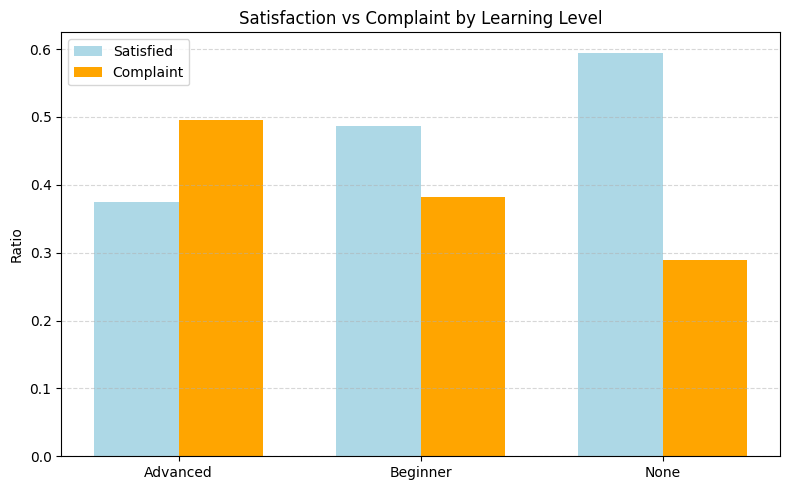

In [21]:
# 그래프
labels = level_satisfied_ratio.index.tolist()
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, level_satisfied_ratio.values, width, label='Satisfied', color='lightblue')
rects2 = ax.bar(x + width/2, level_complaint_ratio.values, width, label='Complaint', color='orange')

ax.set_ylabel('Ratio')
ax.set_title('Satisfaction vs Complaint by Learning Level')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


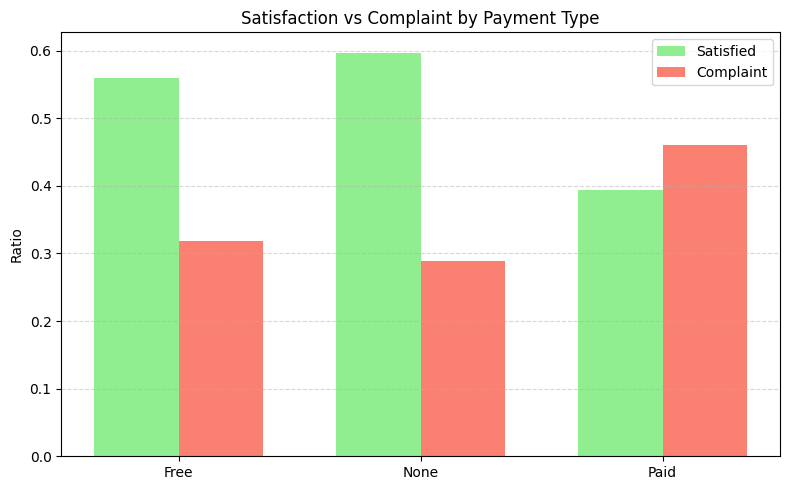

In [22]:
# 그래프
labels = payment_satisfied_ratio.index.tolist()
x = np.arange(len(labels))

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, payment_satisfied_ratio.values, width, label='Satisfied', color='lightgreen')
rects2 = ax.bar(x + width/2, payment_complaint_ratio.values, width, label='Complaint', color='salmon')

ax.set_ylabel('Ratio')
ax.set_title('Satisfaction vs Complaint by Payment Type')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

뚜렷하게 Advanced User가 불만족한 경우가 많았고, 결제한 사람들이 Free 이용자에 비해 불만족한 결과가 나왔다.

명확하게 beginner와 무료 이용자는 더 높은 점수를 주고 있고,
advanced user와 paid user는 더 낮은 리뷰를 주고 있다.

이제, 두 user group(advanced와 paid)의 주요 불만을 분석할 것이다.

In [23]:
advanced_reviews = df[(df['is_complaint']) & (df['level_type'] == 'Advanced')]
paid_reviews = df[(df['is_complaint']) & (df['payment_type'] == 'Paid')]

In [24]:
# Paid review에 대한 분석
texts = paid_reviews[(paid_reviews['score'] <= 2)]['cleaned'].dropna().tolist()
texts = [preprocess(t) for t in texts]

# Redefine the vectorizer here
vectorizer = TfidfVectorizer(max_df=0.9, min_df=10)

dtm = vectorizer.fit_transform(texts)

# LDA 모델 훈련
lda = LatentDirichletAllocation(n_components=5, random_state=42)
lda.fit(dtm)


LatentDirichletAllocation(n_components=5, random_state=42)

In [25]:
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda, dtm, vectorizer)
pyLDAvis.display(panel)

- AI 기반 기능을 포함한 유료 기능 전반에 대한 기대 대비 실망과 더불어, 버전 변경이나 콘텐츠 감소에 대한 아쉬움이 드러난다.
- 앱 업데이트 이후 학습 흐름, 레슨 구성, 하트/제약 시스템 등에 있어 사용자 경험이 악화되었다는 인식이 나타난다.
- 유료 이용자들이 구독, 결제, 환불, 가족 요금제 등 전반적인 요금제 관리 문제에 대한 불만을 표현하고 있다.
- 광고, 하트 시스템, 반복 학습 등 프리미엄 사용자임에도 불구하고 체감하는 불만과 피로감이 드러난다.
- 무료 체험판 이후 자동 결제 및 환불 과정에서 발생한 혼란과 부정적인 경험의 내용을 가진다.


In [26]:
# Advanced review에 대한 분석
texts_adv = advanced_reviews[(advanced_reviews['score'] <= 2)]['cleaned'].dropna().tolist()
texts_adv = [preprocess(t) for t in texts_adv]
dtm_adv = vectorizer.fit_transform(texts)

# LDA 모델 훈련
lda_adv = LatentDirichletAllocation(n_components=5, random_state=42)
lda_adv.fit(dtm_adv)

LatentDirichletAllocation(n_components=5, random_state=42)

In [27]:
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_adv, dtm_adv, vectorizer)
pyLDAvis.display(panel)

- Advanced 사용자들이 유료 결제를 통해 제공받는 AI 기반 기능, 콘텐츠 구성, 버전 변경 등에서 체감한 실망과 업데이트 이후 제거된 기능들에 대해 불만을 나타냈다.
- 최근 업데이트 이후 학습 흐름이 제한되고 하트·시간 제약, 레슨 구성 변화 등으로 인해 유료 서비스의 가치를 충분히 느끼지 못하고 있다는 불만을 나타냈다.
- 프리미엄 구독(Super Duolingo) 관련해 체험판 이후 자동 결제, 구독 취소, 가족 요금제 및 고객 지원 부족 등 전반적인 결제·계정 관리 경험에 대한 실망했다.
- 유료 요금제를 이용하면서도 광고 노출, 반복된 학습 흐름, 제한적인 기능 구성 등에 대해 가성비가 부족하다고 느끼며 불만을 보인다.
- 무료 체험판 종료 후 자동 결제, 환불 실패, 고지 부족 등의 이슈에 대해 강한 불신과 불쾌감을 표현했다.

Advanced그룹과 Paid 그룹에서 공통적인 불만이 나타난다.
ai 기반 컨텐츠에 대한 실망, 앱 업데이트 이후 불만족, 결제 시스템 관련 불만, 유료 서비스임에도 광고와 제약이 존재함을 공통된 불만으로 뽑을 수 있다.

그리고, paid 유저와 advanced 유저의 불만이 공통적으로 나타나는 것을 보아 advanced 유저일수록 유료 회원임을 가정하게 되었다.




/tmp/ipython-input-28-463549003.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered2['group'] = df_filtered2['payment_type'] + ' - ' + df_filtered2['level_type']
/tmp/ipython-input-28-463549003.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=complaint_rate.index, y=complaint_rate.values, palette="Reds_r")


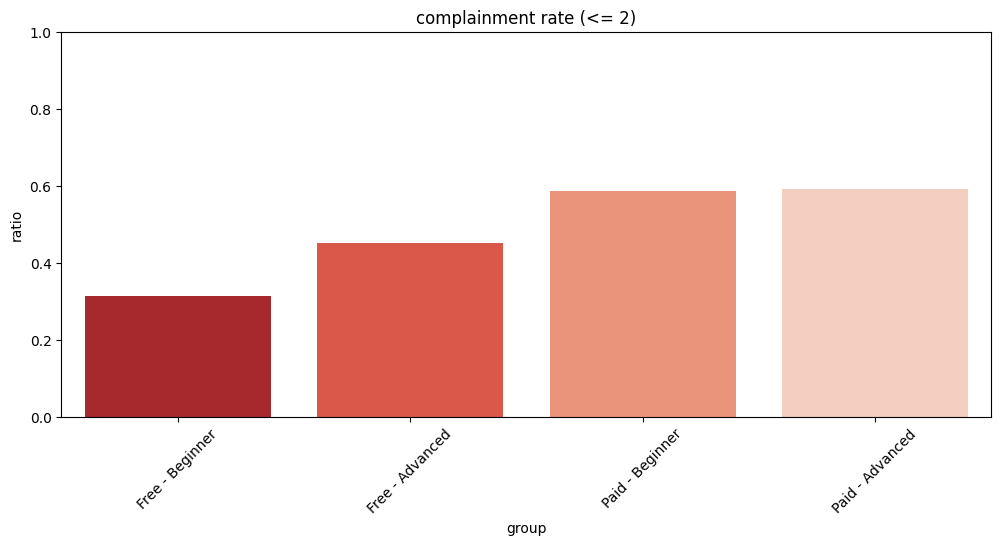

/tmp/ipython-input-28-463549003.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=satisfaction_rate.index, y=satisfaction_rate.values, palette="Blues")


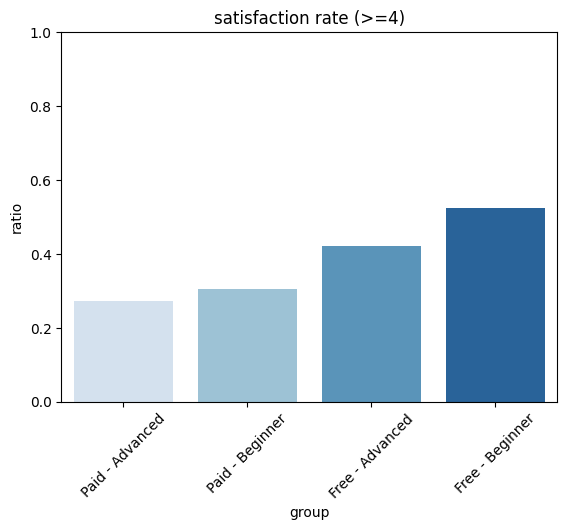

/tmp/ipython-input-28-463549003.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=group_ratio.index, y=group_ratio.values, palette="Greens")


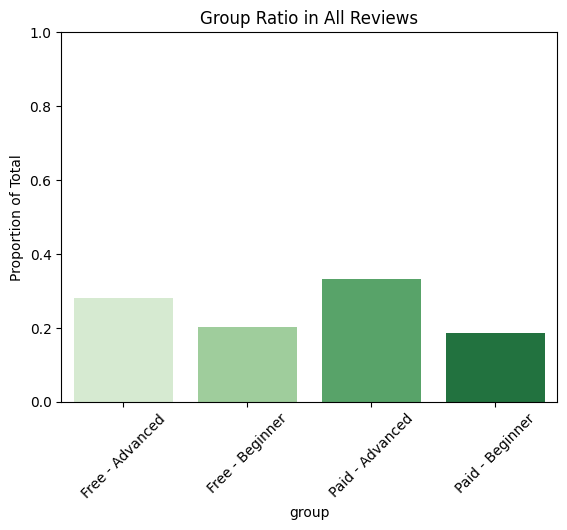

In [28]:
df_filtered2 = df[(df['payment_type'] != 'None') & (df['level_type'] != 'None')]
df_filtered2['group'] = df_filtered2['payment_type'] + ' - ' + df_filtered2['level_type']

# 그룹별 불만율 / 만족도 계산
complaint_rate = df_filtered2.groupby('group')['is_complaint'].mean().sort_values()
satisfaction_rate = df_filtered2.groupby('group')['is_satisfied'].mean().sort_values()
group_ratio = df_filtered2['group'].value_counts(normalize=True).sort_index()
plt.figure(figsize=(12, 5))

# 불만율 시각화
sns.barplot(x=complaint_rate.index, y=complaint_rate.values, palette="Reds_r")
plt.xticks(rotation=45)
plt.title("complainment rate (<= 2)")
plt.ylabel("ratio")
plt.ylim(0, 1)
plt.show()

# 만족도 시각화
sns.barplot(x=satisfaction_rate.index, y=satisfaction_rate.values, palette="Blues")
plt.xticks(rotation=45)
plt.title("satisfaction rate (>=4)")
plt.ylabel("ratio")
plt.ylim(0, 1)
plt.show()


sns.barplot(x=group_ratio.index, y=group_ratio.values, palette="Greens")
plt.xticks(rotation=45)
plt.title("Group Ratio in All Reviews")
plt.ylabel("Proportion of Total")
plt.ylim(0, 1)
plt.show()


advanced user일수록 beginner에 비해 유료 서비스를 많이 이용하며, 불만도 크게 나타난다. 또한, free이용자인 advanced 회원도 불만족 비율이 크다고 판단했다.
이번엔 advanced-free회원과 advanced-paid회원의 불만에는 어떤 차이가 있는지 확인해볼 것이다.

In [29]:
# 두 그룹만 필터링
df_adv = df_filtered2[df_filtered2['group'].isin(['Free - Advanced', 'Paid - Advanced'])]

# 불만율 비교
complaint_by_group = df_adv.groupby('group')['is_complaint'].mean()
print("불만율 비교:")
print(complaint_by_group)


불만율 비교:
group
Free - Advanced    0.451852
Paid - Advanced    0.590625
Name: is_complaint, dtype: float64


/tmp/ipython-input-30-3965423393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=complaint_by_group.index, y=complaint_by_group.values, palette="Reds_r")


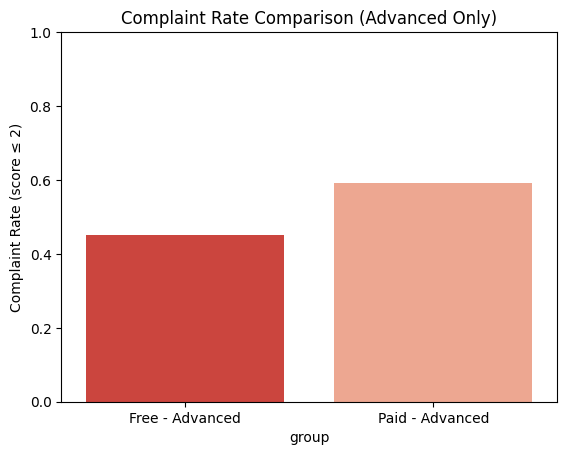

In [30]:
# 그래프
sns.barplot(x=complaint_by_group.index, y=complaint_by_group.values, palette="Reds_r")
plt.title("Complaint Rate Comparison (Advanced Only)")
plt.ylabel("Complaint Rate (score ≤ 2)")
plt.ylim(0, 1)
plt.show()

In [31]:
# 교차표 생성
contingency = pd.crosstab(df_adv['group'], df_adv['is_complaint'])

# 카이제곱 검정 수행
chi2, p, dof, expected = chi2_contingency(contingency)

print("카이제곱 검정 결과:")
print(f"Chi² = {chi2:.4f}, p-value = {p:.10f}")

카이제곱 검정 결과:
Chi² = 22.0745, p-value = 0.0000026227


p-value가 0.05 미만이므로 통계적으로 유의미하게 특성이 클러스터별로 다르게 분포되어 있음을 알 수 있다.

In [32]:
complaint_reviews = df_adv[df_adv['is_complaint']]

In [33]:
# 그룹별 텍스트 병합
grouped_texts = complaint_reviews.groupby('group')['cleaned'].apply(lambda x: ' '.join(x))

# TF-IDF 벡터화
vectorizer = TfidfVectorizer(stop_words=list(stop_words), max_features=1000)
tfidf_matrix = vectorizer.fit_transform(grouped_texts)

# 결과
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), index=grouped_texts.index, columns=vectorizer.get_feature_names_out())
top_keywords = tfidf_df.T.apply(lambda x: x.sort_values(ascending=False).head(15)).T
print("그룹별 상위 불만 키워드:\n", top_keywords)

그룹별 상위 불만 키워드:
                       ads        ai      cant       day      dont      free  \
group                                                                         
Free - Advanced  0.203867       NaN  0.126309  0.117445       NaN  0.511884   
Paid - Advanced  0.217096  0.136047       NaN       NaN  0.131705  0.166441   

                   hearts       ive  language    lesson   lessons       new  \
group                                                                         
Free - Advanced  0.226027  0.170628  0.159548  0.137389  0.126309  0.139605   
Paid - Advanced  0.193939  0.196834  0.133152       NaN  0.156309  0.143284   

                     paid   premium    streak     super      time    update  \
group                                                                         
Free - Advanced       NaN       NaN  0.168412       NaN  0.124093  0.130741   
Paid - Advanced  0.327497  0.276643       NaN  0.127363       NaN  0.138942   

                  version     yea

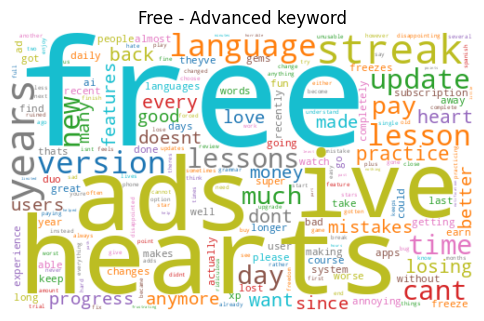

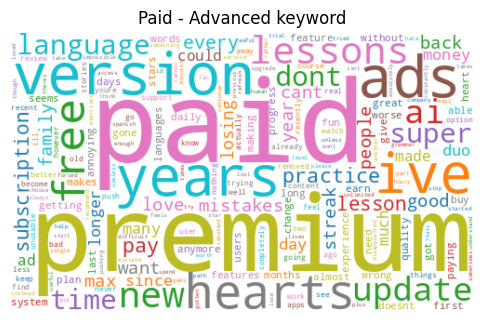

In [34]:
free_dict = tfidf_df.loc['Free - Advanced'].dropna().to_dict()
paid_dict = tfidf_df.loc['Paid - Advanced'].dropna().to_dict()

# 워드클라우드 함수
def plot_wordcloud(word_freq_dict, title):
    wc = WordCloud(width=500, height=300, background_color='white', colormap='tab10')
    wc.generate_from_frequencies(word_freq_dict)
    plt.figure(figsize=(6, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

plot_wordcloud(free_dict, 'Free - Advanced keyword')
plot_wordcloud(paid_dict, 'Paid - Advanced keyword')

- Free - Advanced
  free (0.51): 무료 체험, 잠금 해제 안 됨 등의 이슈

  ads, hearts, streak, lesson, cant 등: 광고·학습 제한·하트 시스템 관련 불만

  결론: 기능 제한, 광고, 반복 학습 시스템에 대한 피로와 불만이 많음

- Paid - Advanced
paid (0.33), premium (0.28), super (0.13): 유료 구독자 정체성과 결제 관련 언급이 많음

  ai (0.14), dont, refund, update, version 등도 Paid 쪽에서 더 나타남

  결론: AI 기능 실망, 기능 축소, 버전 다운그레이드, 환불 이슈 등 프리미엄 기대 불일치에 대한 불만 집중

- Free - Advanced: 광고, 하트, 잠금·제한 등 기본 기능 제약에 대한 불만이 주로 분포하고 있다.

-  Paid - Advanced: AI 기능 실망, 버전 다운, 가성비, 결제 관련 불만을 중심으로 돈을 냈지만 불편함을 문제로 삼고 있다.

## 가설3: AI 품질/정확성에 대한 불만이 다른 AI 기능의 불만보다 많을 것이다.

AI 관련 리뷰 중 score가 2 이하인 리뷰를 선별한 뒤, 해당 리뷰에 LDA 주제 모델링을 적용하여 3개의 주요 토픽을 뽑았다.

In [35]:
df_ai = df[(df['ai_mentioned']) & (df['is_complaint'])]

In [36]:
# 벡터화
vectorizer = CountVectorizer(stop_words=list(stop_words), max_df=0.95, min_df=5)
X = vectorizer.fit_transform(df_ai['cleaned'])

# LDA
lda_3 = LatentDirichletAllocation(n_components=3, random_state=42)
lda_3.fit(X)

# 토픽별 주요 키워드 확인
terms = vectorizer.get_feature_names_out()
for idx, topic in enumerate(lda_3.components_):
    print(f"Topic {idx}: ", [terms[i] for i in topic.argsort()[-20:]])

Topic 0:  ['update', 'dont', 'ive', 'practice', 'since', 'new', 'super', 'paid', 'features', 'every', 'pay', 'years', 'free', 'hearts', 'worse', 'time', 'lesson', 'subscription', 'lessons', 'ads']
Topic 1:  ['doesnt', 'teaching', 'instead', 'wrong', 'time', 'lessons', 'grammar', 'much', 'never', 'better', 'good', 'words', 'real', 'actually', 'want', 'teach', 'languages', 'people', 'dont', 'language']
Topic 2:  ['better', 'dont', 'ive', 'quality', 'employees', 'years', 'day', 'humans', 'replace', 'support', 'good', 'workers', 'replacing', 'going', 'streak', 'company', 'people', 'first', 'human', 'language']


In [37]:
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(lda_3, X, vectorizer)
pyLDAvis.display(panel)

토픽들이 명확하게 구분되었다.

토픽들의 각 키워드를 확인해볼 때,
topic0는 광고, 하트 시스템 등 유료 서비스 또는 기능에 대한 불만으로 보인다.
topic1은 언어 교육 방식에 대한 불만으로 보인다. 문법에는 학습하기 좋지만, 회화는 좀 어렵다 등 교육 방식에 대한 불민이다.
마지막으로 topic2는 직원을 대규모 해고하고, aifirst를 도입하여 일어난 불만으로 보인다. 내용을 자세히 보면, real, disappointed, quality 등을 보면 그로 인해 더 부자연스러운 표현, 품질이 저하되어 실망감을 느끼고 있다.

이전에 구분한 주제3개를 비율이 어떻게 나눠지는 지를 구분해보겠다.

In [39]:
topic_distribution = lda_3.transform(X)
assigned_topic = np.argmax(topic_distribution, axis=1)
df_ai['complaint_type'] = assigned_topic
topic_counts = df_ai['complaint_type'].value_counts()
print("전체 불만 주제 분포:")
print(topic_counts)
print(f"\n전체 비율:")
print(topic_counts / topic_counts.sum() * 100)

전체 불만 주제 분포:
complaint_type
2    1469
0    1107
1     821
Name: count, dtype: int64

전체 비율:
complaint_type
2    43.244039
0    32.587577
1    24.168384
Name: count, dtype: float64


/tmp/ipython-input-39-1420077889.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ai['complaint_type'] = assigned_topic


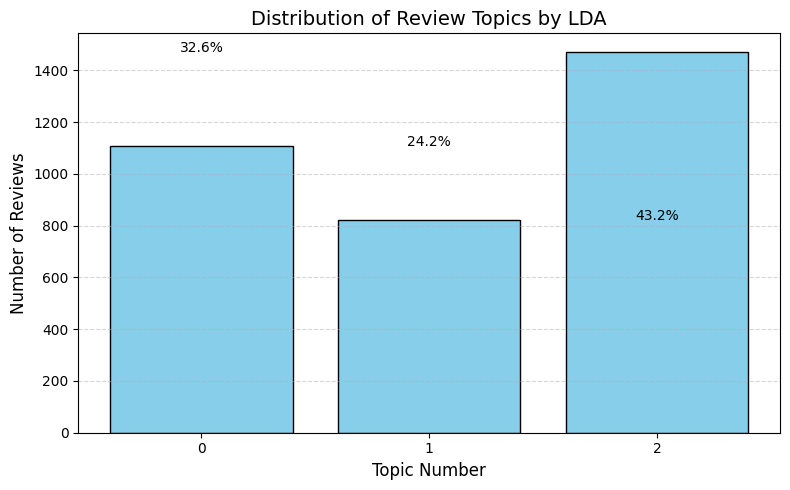

In [40]:
# Topic count and proportions
topic_counts = df_ai['complaint_type'].value_counts()
topic_props = topic_counts / topic_counts.sum() * 100

# Visualization
plt.figure(figsize=(8, 5))
bars = plt.bar(topic_counts.index, topic_counts.values, color='skyblue', edgecolor='black')

# Add percentage labels
for i, count in enumerate(topic_counts.values):
    plt.text(i, count + 2, f"{topic_props[i]:.1f}%", ha='center', fontsize=10)

plt.title("Distribution of Review Topics by LDA", fontsize=14)
plt.xlabel("Topic Number", fontsize=12)
plt.ylabel("Number of Reviews", fontsize=12)
plt.xticks(topic_counts.index)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


확실히 topic2(ai 대체로 인한 품질 저하)에 대한 비율이 가장 크게 나타났다.

이번엔 topic2가 다른 주제들에 비해 통계적으로 유의미한 차이가 나타나는지 카이 제곱 검정으로 확인해볼 것이다.

귀무가설(H₀):
AI 도입/사람 대체에 대한 불만(Topic 2)의 리뷰 비율은 다른 불만 유형들과 통계적으로 유의미한 차이가 없다. (즉, 모든 토픽은 비슷한 비율로 나타난다)

대립가설(H₁):
AI 도입/사람 대체에 대한 불만(Topic 2)은 다른 주제보다 통계적으로 유의미하게 더 많이 혹은 적게 나타난다.

In [41]:
topic_counts = df_ai['complaint_type'].value_counts().sort_index()
chi2_stat, p_val = chisquare(topic_counts)

print(f"Chi-square statistic: {chi2_stat:.4f}")
print(f"p-value: {p_val:.4e}")

Chi-square statistic: 186.2655
p-value: 3.5724e-41


AI 도입 및 인간 대체와 관련된 품질 저하에 대한 불만은 통계적으로 유의미하게 많이 등장하고 있음을 알 수 있다.



사용자들은 AI 도입으로 인해 발생한 대규모 인력 감축과, 그에 따른 서비스 품질 저하(특히 번역 정확도)에 대해 강한 불만을 드러내고 있다.
처음에는 "AI 품질/정확성에 대한 불만이 다른 AI 기능의 불만보다 많을 것이다"라는 가설(가설 3)을 설정했으나, 실제 분석 결과를 바탕으로 해당 가설은 다음과 같이 더 구체화되고 확장되었다:
> AI 도입으로 인한 인간 인력의 축소가 직접적으로 서비스 품질 저하로 이어졌고, 이에 대한 사용자 불만이 타 기능 불만보다 유의미하게 많다.

이러한 확장은 단순한 기능 수준의 문제 제기를 넘어, 사용자들이 서비스 운영 구조에 내재한 문제를 파악하고 비판하고 있음을 알게 해준다.